## Bethe-Bloch Simulation

In [1]:
import numpy as np
import scipy.constants as con

def beta(T: float, E_0: float):
    """
    :T: Kinetische Energie des Teilchens in eV
    :E_0: Ruheenergie des Teilchens in eV
    """
    gamma = (T/E_0)+1
    return np.sqrt(1-1/gamma**2)

class Material:
    def __init__(self, Z, A, I, n):
        """
        :Z: Ladungszahl
        :A: Massenzahl
        :I: mittlere Ionisationsenergy (in J)
        :n: Dichte in g/cm³
        """
        self.I = I
        self.n_e = Z*n*1e3/A/con.u
        self.rho = n

Au = Material(79, 197, 790*con.e, 19.32)
Si = Material(14, 28, 173*con.e, 2.33)

def Bethe(target: Material, E: float, z=2, E0=3728e6):
    """
    :target: Zielmaterial
    :E: Kinetische Energie des Teilchens in eV
    :z: Ladungszahl des Teilchens
    :E0: Ruheenergie des Teilchens in eV
    """
    n = target.n_e
    I = target.I
    B2 = beta(E, E0)**2
    #a = (4 * np.pi * n * z**2) / (con.m_e * con.c**2 * B2) # Henrik
    a = (4*np.pi*n*z**2)/(con.m_e*con.c**2*B2)
    #b = ((con.e**2) / (4 * np.pi * con.epsilon_0))**2 # Henrik
    b = (con.e**2/(4*np.pi*con.epsilon_0))**2
    #c = np.log((2 * con.m_e * con.c**2 * B2) / (I * (1 - B2))) - B2 # Henrik
    c = np.log((2*con.m_e*con.c**2*B2)/(I*(1-B2))) - B2
    return a * b * c #* 6.241509074460763e+18 * 1e-6 * 1e-2

def Bethe_old(target: Material, E:float, z=2, E0=3728e6):
    """
    :target: Zielmaterial
    :E: Kinetische Energie des Teilchens in eV
    :z: Ladungszahl des Teilchens
    :E0: Ruheenergie des Teilchens in eV
    """
    n = target.n_e
    I = target.I
    B2 = beta(E, E0)**2
    a = (4*np.pi*n*z**2)/(con.m_e*con.c**2*B2)
    b =(con.e**2/(4*np.pi*con.epsilon_0))**2
    c = np.log((2*con.m_e*con.c**2*B2)/(I*(1-B2))) - B2
    return a * b * c

def Reichweite(target: Material, E: float, dx=1e-6, Elim=1.0):
    """
    :target: Materialeigenschaften des Zielmaterials
    :E: Kinetische Energie des Teilchens in eV
    :dx: Schrittweite in m
    """
    l = 0
    while E > Elim: # in eV
        lost = Bethe(target, E) / con.e * dx # Energieverlust in eV
        E -= abs(lost)
        l += dx
    return l *100 * target.rho

In [4]:
E = np.logspace(3, 9, 1000, endpoint=True)

vBethe = np.vectorize(Bethe)
vReich = np.vectorize(Reichweite)

dEdx = Bethe(Si, E)
rw = []
for i in E:
    rw.append(Reichweite(Si, i, dx=1e-6))
rw = np.array(rw)

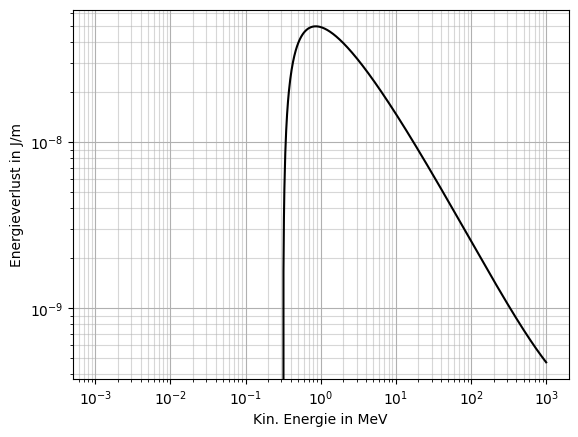

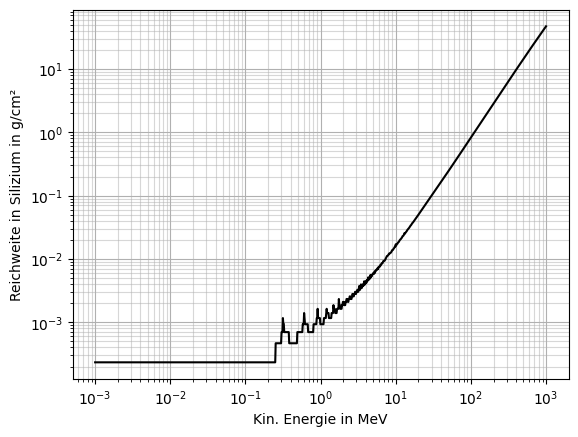

In [5]:
import matplotlib.pyplot as plt

plt.plot(E/1e6, dEdx, '-k')
plt.xscale('log')
plt.yscale('log')
plt.ylabel('Energieverlust in J/m')
plt.xlabel('Kin. Energie in MeV')
plt.minorticks_on()
plt.grid(which='major')
plt.grid(which='minor', alpha=0.5)

fig, ax = plt.subplots()
ax.plot(E/1e6, rw, '-k')


ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('Kin. Energie in MeV')
ax.set_ylabel('Reichweite in Silizium in g/cm²')

ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)


plt.show()

## Linearitätsprüfung

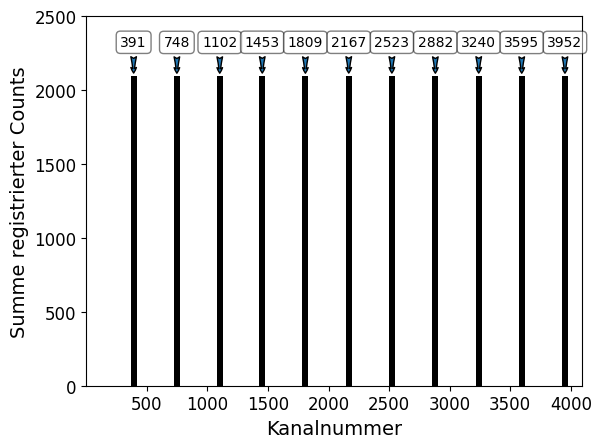

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

chans = []
sums = []

for file in os.listdir(r'../Messdaten/19012026_Halbleiter/3_neu/'):
    data = np.loadtxt(f'../Messdaten/19012026_Halbleiter/3_neu/{file}')
    ii = 0 # sum of all channels
    iii = 0 # number of channels
    xx = 0 # sum of all counts
    for i, x in enumerate(data):
        if i == 0 or i == 1: # skip live/real time channels
            continue
        if x > 0:
            iii += 1
            ii += i
            xx += x
    chans.append(int(ii/iii)+1)
    sums.append(xx)

fig, ax = plt.subplots()

for chan, sum in zip(chans, sums):
    ax.bar(chan, sum, width=50, color='k')
    ax.annotate(str(chan), (chan,sum), (chan, sum+200), arrowprops={'arrowstyle': 'fancy'}, ha='center', bbox={'boxstyle':'round', 'alpha':0.5, 'fc':'white', 'ec':'black'})

ax.set_xlabel("Kanalnummer", fontsize=14)
ax.set_ylabel("Summe registrierter Counts", fontsize=14)
ax.tick_params(axis='both', labelsize=12)
ax.set_xlim(1, 4096)
ax.set_ylim(0, 2500)
plt.show()

y=0.00140381(0.00000107) * x -0.0452(0.0026)


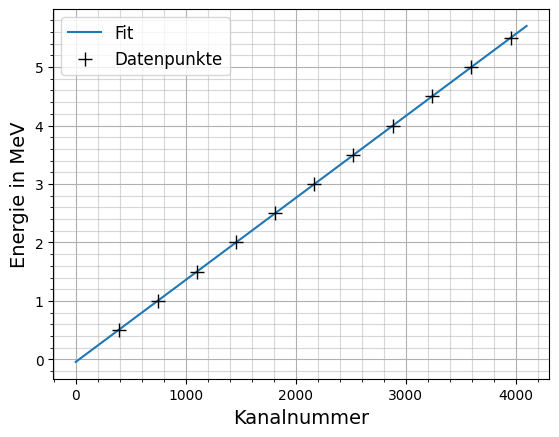

In [2]:
from scipy.stats import linregress
Energien = np.arange(0.5, 6., 0.5) # in MeV

# fit
linfit = linregress(chans, Energien)
slope, sloperr, intercept, intercepterr = linfit.slope, linfit.stderr, linfit.intercept, linfit.intercept_stderr
print(f"y={slope:.8f}({sloperr:.8f}) * x {intercept:.4f}({intercepterr:.4f})")

def Energie(kanal: np.ndarray, slope=0.0014038, intercept=-0.045) -> np.ndarray:
    """
    :kanal: Kanalnummer
    :slope: Steigung der Energie/Kanal Gerade
    :intercept: Ordinatenabschnitt der Energie/Kanal Gerade

    Berechnet die zu einem Kanal gehörige Energie in MeV
    """
    return slope * kanal + intercept

def Kanal(energie: np.ndarray, slope=0.0014038, intercept=-0.045) -> np.ndarray:
    """
    :energie: Energie in MeV
    :slope: Steigung der Energie/Kanal Gerade
    :intercept: Ordinatenabschnitt der Energie/Kanal Gerade

    Berechnet den zu einer Energie gehörigen Kanal
    """
    return np.round((energie - intercept ) / slope)

x = np.arange(1, 4097)
plt.plot(x, slope*x+intercept)
for chan, E in zip(chans, Energien):
    plt.plot(chan, E, '+k', ms=10)
plt.xlabel("Kanalnummer", fontsize=14)
plt.ylabel("Energie in MeV", fontsize=14)
ax.tick_params(axis='both', labelsize=12)
plt.legend(["Fit", "Datenpunkte"], fontsize=12)

plt.minorticks_on()
plt.grid(which='major')
plt.grid(which='minor', alpha=0.5)
plt.show()

## $\alpha$-Spektrum fits

## Rauschen und Impulshöhe bei kapazitiver Last

In [3]:
colors = ['tab:cyan', 'tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:grey', 'tab:olive', 'tab:brown']

rauschen = {"0pF": np.nan,
            "20pF": np.nan,
            "95pF": np.nan,
            "245pF": np.nan,
            "320pF":np.nan,
            "770pF": np.nan,
            "1020pF": np.nan,
            "1770pF": np.nan}

detektor = {"0V": np.nan,
            "1V": np.nan,
            "2V": np.nan,
            "3V": np.nan,
            "4V": np.nan,
            "5V": np.nan,
            "10V": np.nan,
            "20V": np.nan,
            "40V": np.nan}

0pF HWB=0.00464073(3.51654e-06) MeV [5.00683080e+00 1.97073610e-03 1.19238146e+03]
20pF HWB=0.00519453(2.76761e-06) MeV [5.00607513e+00 2.20591394e-03 2.11733676e+03]
95pF HWB=0.0075668(2.37906e-06) MeV [5.00423739e+00 3.21332331e-03 1.46340343e+03]
245pF HWB=0.010838(6.57105e-06) MeV [5.00128681e+00 4.60247931e-03 1.52955591e+03]
320pF HWB=0.013016(1.07256e-05) MeV [5.00020278e+00 5.52737775e-03 1.21986780e+03]
770pF HWB=0.0197759(2.0118e-05) MeV [4.99478230e+00 8.39804688e-03 5.59402234e+02]
1020pF HWB=0.0214256(2.03582e-05) MeV [4.99255490e+00 9.09862243e-03 5.17460510e+02]
1770pF HWB=0.0230052(1.59987e-05) MeV [4.98890667e+00 9.76941571e-03 9.60696672e+02]
0V HWB=0.0467582(5.22814e-05) MeV [4.99768783e+00 1.98563625e-02 5.33508715e+02]
1V HWB=0.0452026(4.99684e-05) MeV [4.99812365e+00 1.91957770e-02 6.49375386e+02]
2V HWB=0.0452064(4.69845e-05) MeV [4.99754528e+00 1.91973902e-02 5.30787012e+02]
3V HWB=0.0449285(7.73563e-05) MeV [4.99696889e+00 1.90793849e-02 2.46459717e+02]
4V HWB=

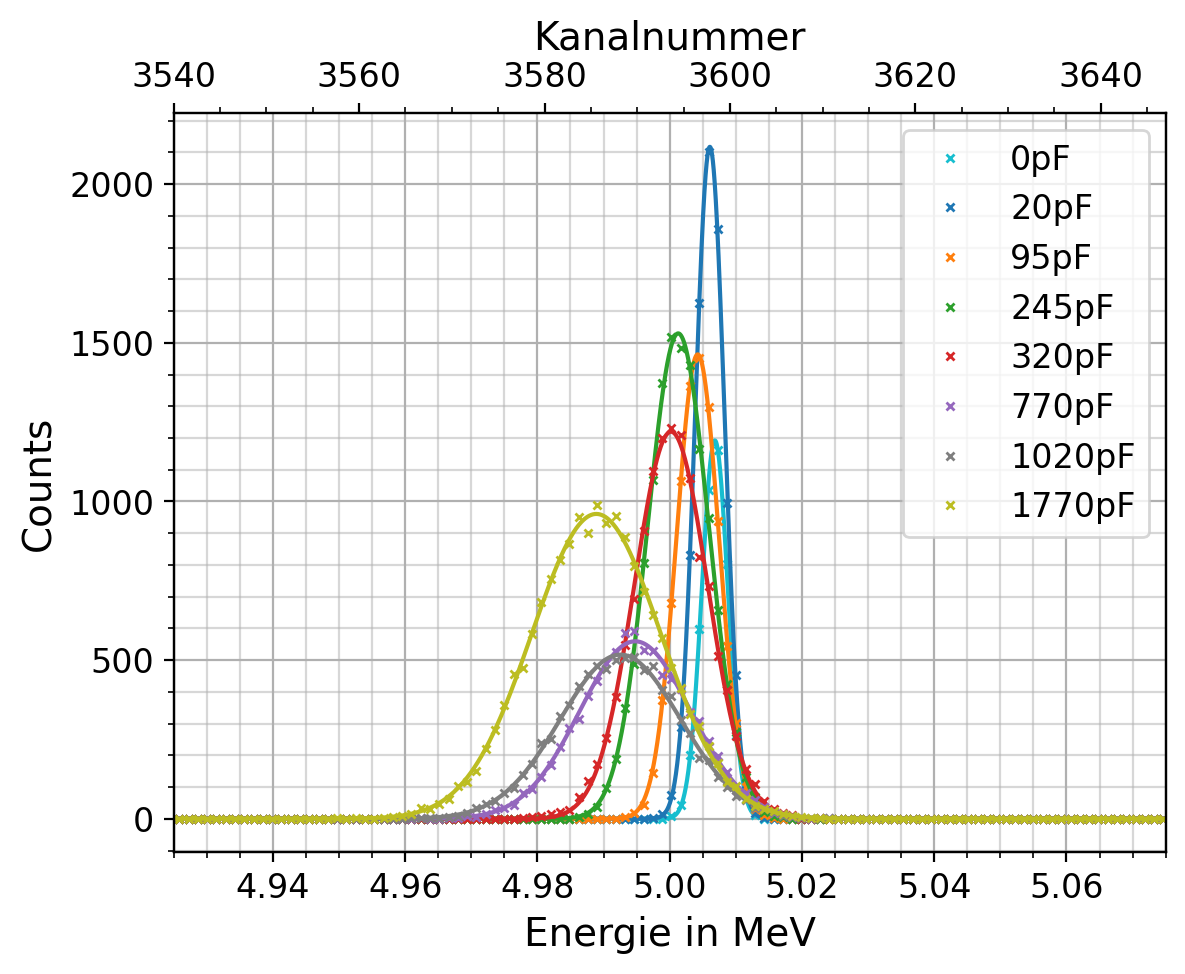

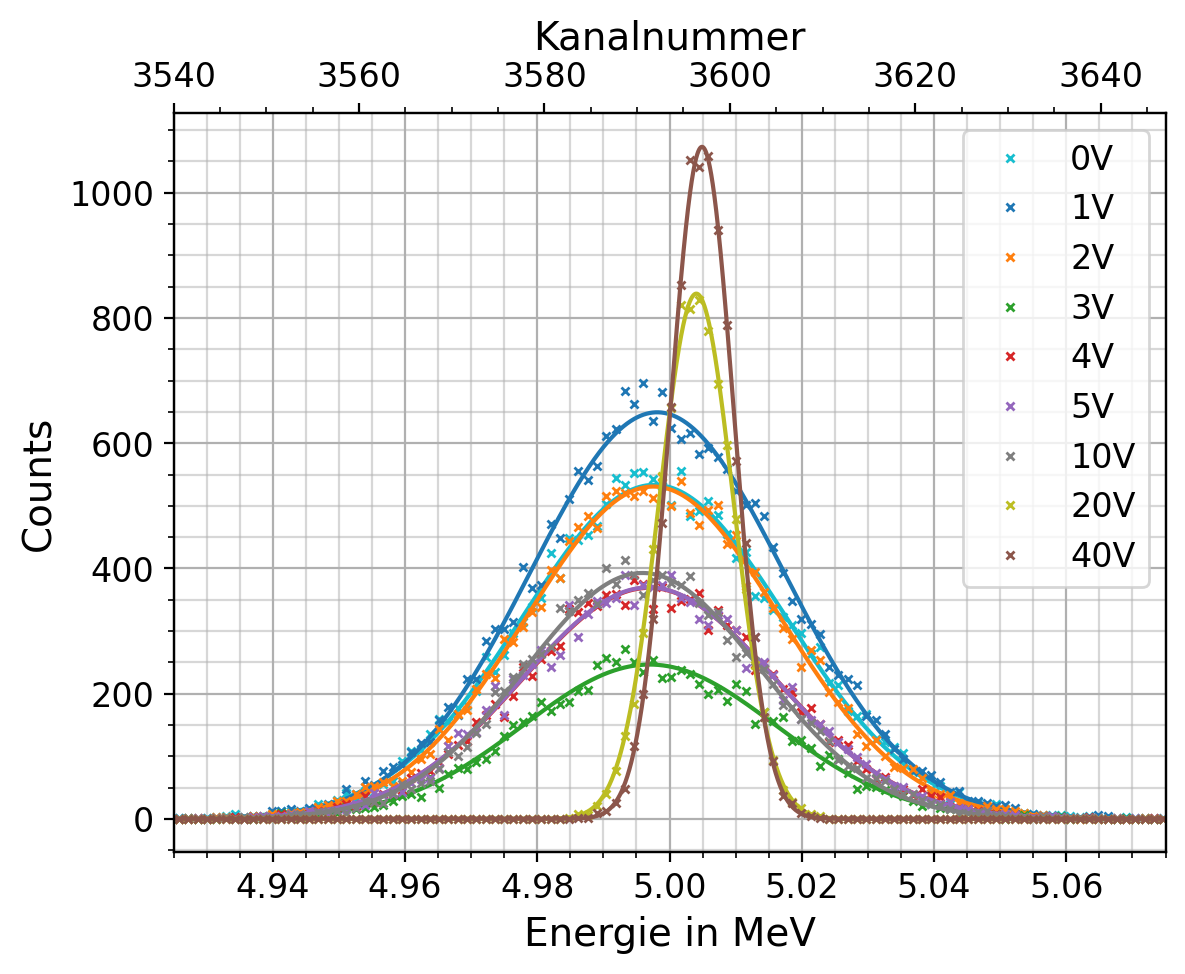

In [54]:
from scipy.optimize import curve_fit

def Gauss(x, mu, sig, A):
    return A*np.exp(-(x-mu)**2/(2*sig**2))

fig1, kap = plt.subplots(dpi=200)
fig2, det = plt.subplots(dpi=200)

xllim = 4.925
xulim = 5.075

HWBpf = []
HWBV = []

for ax in [kap, det]:
    ax2 = ax.twiny()
    ax.set_xlim(xllim, xulim)
    ax2.set_xlim(Kanal(ax.get_xlim()[0]), Kanal(ax.get_xlim()[1]))
    ax2.set_xlabel("Kanalnummer", fontsize=14)
    ax.minorticks_on()
    ax2.minorticks_on()
    ax.grid(which='major')
    ax.grid(which='minor', alpha=0.5)
    ax.set_xlabel("Energie in MeV", fontsize=14)
    ax.set_ylabel("Counts", fontsize=14)
    ax.tick_params(axis='both', labelsize=12)
    ax2.tick_params(axis='both', labelsize=12)

for file in os.listdir(r'../Messdaten/19012026_Halbleiter/4_Rauschen/'):
    if file == "kaputt":
        continue
    indicator = file.split("_")[1].split(".")[0] # XXpf or XXV
    if indicator in [*list(rauschen), *list(detektor)]:
        data = np.loadtxt(f'../Messdaten/19012026_Halbleiter/4_Rauschen/{file}')[2:]
    if indicator[-1] == "F":
        rauschen[indicator] = data
    elif indicator[-1] == "V":
        detektor[indicator] = data

for dataset in [rauschen, detektor]:
    for i, (key, data) in enumerate(zip(list(dataset), list(dataset.values()))):
        xx = np.arange(3, 4097)
        x = Energie(xx)
        x_cont = np.arange(xllim, xulim, 1e-6)
        guess = [5, 1e-2, 10]
        popt, pcov = curve_fit(Gauss, x, data, p0=guess)
        perr = np.sqrt(np.diag(pcov))
        if dataset == rauschen:
            HWBpf.append((2*np.sqrt(2*np.log(2))*popt[1], 2*np.sqrt(2*np.log(2))*perr[1]))
        elif dataset == detektor:
            HWBV.append((2*np.sqrt(2*np.log(2))*popt[1], 2*np.sqrt(2*np.log(2))*perr[1]))
        print(key, f"HWB={2*np.sqrt(2*np.log(2))*popt[1]:.6g}({2*np.sqrt(2*np.log(2))*perr[1]:.6g}) MeV", popt)
        color=colors[i]

        if dataset == detektor:
            det.plot(x, data, 'x', label=key, ms=3, c=color)
            det.plot(x_cont, Gauss(x_cont, *popt), '-', c=color)
        else:
            kap.plot(x, data, 'x', label=key, ms=3, c=color)
            kap.plot(x_cont, Gauss(x_cont, *popt), '-', c=color)

HWBV = np.array(HWBV)
HWBpf = np.array(HWBpf)


for ax in [kap, det]:
    ax.legend(loc=1, fontsize=12)


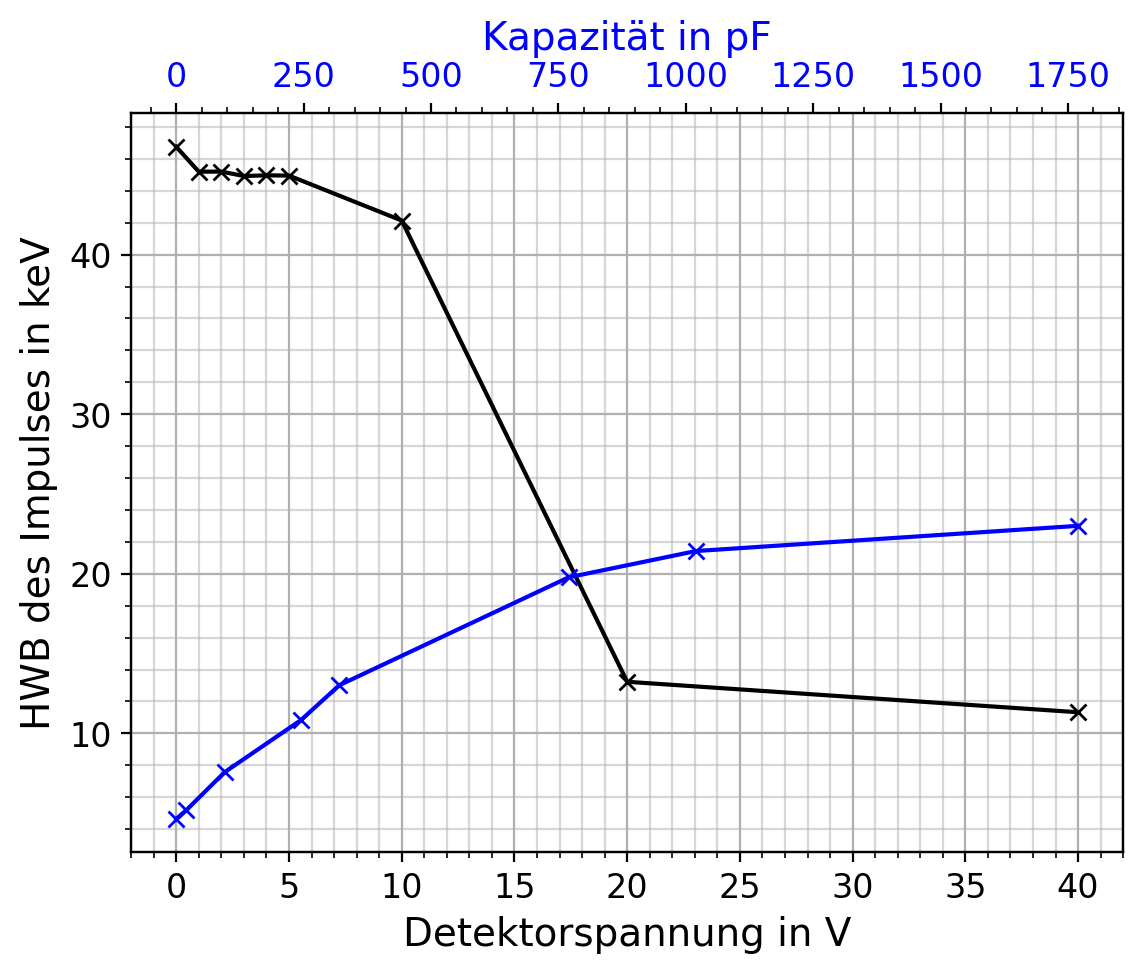

In [ ]:
# Darstellung der HWB Trends

V = np.array([0, 1, 2, 3, 4, 5, 10, 20, 40])
pF = np.array([0, 20, 95, 245, 320, 770, 1020, 1770])

fig, ax = plt.subplots(dpi=200)
ax2 = ax.twiny()

ax.plot(V, HWBV[:,0]*1e3, "x-k")
ax2.plot(pF, HWBpf[:,0]*1e3, "x-b")

ax.set_xlabel("Detektorspannung in V", fontsize=14)
ax2.set_xlabel("Kapazität in pF", fontsize=14, color="b")
ax.set_ylabel("HWB des Impulses in keV", fontsize=14)
ax.tick_params(axis='both', labelsize=12)
ax2.tick_params(axis='x', which="both", labelsize=12, labelcolor="b")

ax.minorticks_on()
ax2.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)

plt.show()
# zwei gleiche HWB entsprechen gleicher Kapazität
# bei Mehr Spannung, größere Verarmungszone, weniger Kapazität, C = µ A/d
# bei 40V entspricht 230(30) pF